## Training an MLP for classification
Today we cover the real essentials for training neural nets. 
- defining a multi-layer perceptron
- define the loss function
- Look at gradient tracking in Pytorch
- Train with SGD

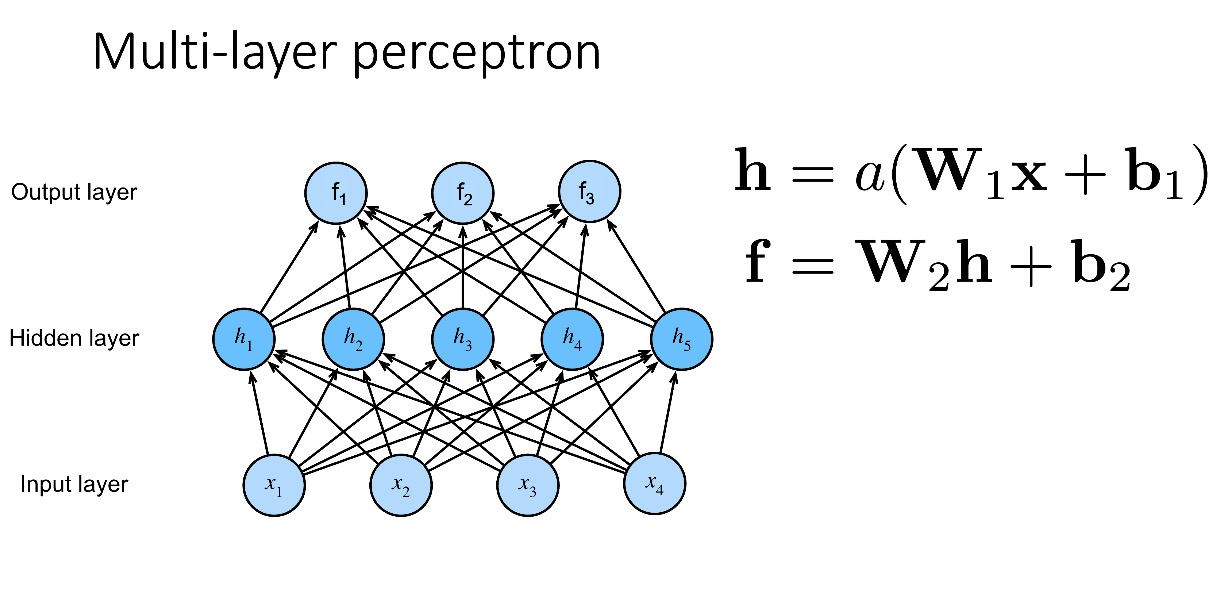

In [93]:
from IPython.display import Image
Image(filename='mlp.jpg')

In [1]:
import torch
import torch.nn as nn  # Neural Net stuff!
from torch.utils.data import DataLoader, TensorDataset  # Data stuff!

from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
%matplotlib inline

# Just changes how numbers display
torch.set_printoptions(sci_mode=False, precision=2)

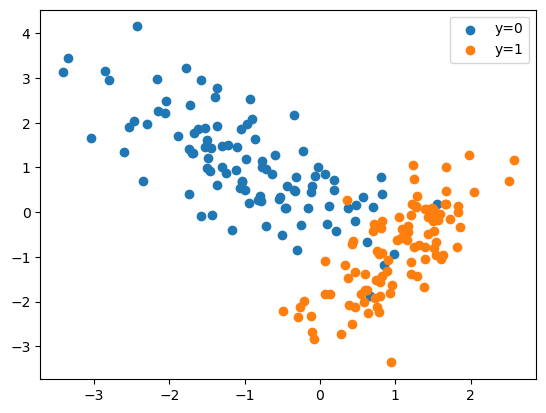

In [64]:
# Build some synthetic data
X, y = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, n_repeated=0, n_clusters_per_class=1, random_state=8)
# Let's look at the data
plt.scatter(X[y==0,0], X[y==0,1], label='y=0')
plt.scatter(X[y==1,0], X[y==1,1], label='y=1')
plt.legend()

X_val, y_val = torch.tensor(X[100:], dtype=torch.float32), torch.tensor(y[100:], dtype=torch.long)
X, y = torch.tensor(X[:100], dtype=torch.float32), torch.tensor(y[:100], dtype=torch.long)

In [8]:
# Let's design a multi-layer perceptron!
class MyMLP(nn.Module):
    def __init__(self, n_hidden=5):
        super(MyMLP, self).__init__()  # init the super-class
        self.dummy = nn.Parameter(t.tensor(0.))  # not using today
        # We'll the layer interface
        self.fc1 = nn.Linear(2, n_hidden)  # input dim=2, 10 hidden units
        # linear does W x + b... it declares parameters, W,b, Initializes
        self.relu1 = nn.ReLU()  # Nonlinear activation function - no parameters
        
        # add some more hidden layers?
        self.fc2 = nn.Linear(n_hidden, n_hidden)
        self.relu2 = nn.ReLU()  # Do we need multiple reLUs? No
        
        # self.fc_list = [nn.Linear(n_hidden, n_hidden) for i in range(100)] # 100 layers!!
        
        self.fc3 = nn.Linear(n_hidden, 2)  # 2 logits = 2 classes
        

    def forward(self, x):
        h1 = self.relu1(self.fc1(x))  # h in diagram
        h2 = self.relu2(self.fc2(h1))
        logits = self.fc3(h2)
        return logits


In [16]:
# Inspect this model - parameters, layers
model = MyMLP(n_hidden=10)
list(model.parameters())[2]

Parameter containing:
tensor([ 0.31,  0.02, -0.03, -0.38,  0.08, -0.69, -0.09, -0.23,  0.11,  0.43],
       requires_grad=True)

In [27]:
# Run it - look at logits, gradients
model(X[:4])

tensor([[-0.34, -0.11],
        [-0.25, -0.10],
        [-0.50, -0.03],
        [-0.25, -0.10]], grad_fn=<AddmmBackward0>)

In [29]:
# Getting probabilities instead of logits
model(X[:4]).softmax(dim=1)

tensor([[0.44, 0.56],
        [0.46, 0.54],
        [0.39, 0.61],
        [0.46, 0.54]], grad_fn=<SoftmaxBackward0>)

In [40]:
# Loss
criterion = nn.CrossEntropyLoss()  # define the loss to use - criterion is a function we can invoke on data

logits = model(X)
loss = criterion(logits, y)
loss  # similar to ln(2) - expected p(y)=0.5.  Global min = 0

tensor(0.74, grad_fn=<NllLossBackward0>)

In [41]:
# Backward pass - look at gradients
model.zero_grad()  # reset the gradients

logits = model(X)
loss = criterion(logits, y)  # calculate loss - FORWARD PASS

loss.backward() # BACKWARD PASS
b1.grad  # now the gradient is populated - gradient of loss wrt b1. Each parameter has this

tensor([-0.01,  0.02,  0.00, -0.01,  0.01, -0.01,  0.00, -0.00, -0.02,  0.03])

In [56]:
# Now let's train
model = MyMLP(n_hidden=5)  # initialize the model

# data loaders
train_loader = DataLoader(TensorDataset(X, y), batch_size=10, shuffle=True)  
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=50, shuffle=True)  

# Loss function
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, weight_decay=0.)

In [58]:
# Training loop
n_epochs = 50
for i in range(n_epochs):
    for x_batch, y_batch in train_loader:
        model.zero_grad()  # reset gradients
        logits = model(x_batch)
        loss = criterion(logits, y_batch)  # forward pass
        loss.backward()  # backward pass
        optimizer.step()  # implements the gradient descent step
        print(f'Train Loss: {loss.item():.3f}')
        
    # Validation loop, every k epochs
    model.eval()  # train vs eval mode   A huge source of bugs
    val_loss = 0.0
    with torch.no_grad():  # no gradients needed not training 
        for x_batch, y_batch in val_loader:
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item() / len(val_loader)
    print(f'Val Loss: {val_loss:.3f}')
    model.train()  # back to train mode

Train Loss: 0.136
Train Loss: 0.081
Train Loss: 0.080
Train Loss: 0.047
Train Loss: 0.162
Train Loss: 0.114
Train Loss: 0.091
Train Loss: 0.160
Train Loss: 0.112
Train Loss: 0.092
Val Loss: 0.180
Train Loss: 0.075
Train Loss: 0.125
Train Loss: 0.122
Train Loss: 0.099
Train Loss: 0.070
Train Loss: 0.109
Train Loss: 0.164
Train Loss: 0.092
Train Loss: 0.093
Train Loss: 0.100
Val Loss: 0.178
Train Loss: 0.104
Train Loss: 0.125
Train Loss: 0.065
Train Loss: 0.118
Train Loss: 0.070
Train Loss: 0.093
Train Loss: 0.091
Train Loss: 0.146
Train Loss: 0.108
Train Loss: 0.101
Val Loss: 0.177
Train Loss: 0.102
Train Loss: 0.120
Train Loss: 0.117
Train Loss: 0.089
Train Loss: 0.078
Train Loss: 0.103
Train Loss: 0.072
Train Loss: 0.093
Train Loss: 0.073
Train Loss: 0.147
Val Loss: 0.175
Train Loss: 0.065
Train Loss: 0.131
Train Loss: 0.073
Train Loss: 0.169
Train Loss: 0.097
Train Loss: 0.072
Train Loss: 0.058
Train Loss: 0.087
Train Loss: 0.120
Train Loss: 0.095
Val Loss: 0.174
Train Loss: 0.063
Tr

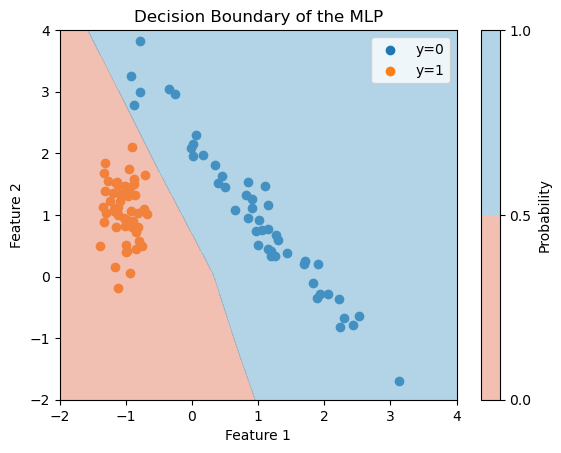

In [59]:
# Plot the nonlinear classifier boundary!

plt.scatter(X[y==0,0], X[y==0,1], label='y=0')
plt.scatter(X[y==1,0], X[y==1,1], label='y=1')
plt.legend()

x_min, x_max = -2, 4
y_min, y_max = -2, 4
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Use the model to predict the class for each point on the grid
with torch.no_grad():
    grid = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float()
    logits = model(grid)[:,0]
    probabilities = torch.sigmoid(logits).numpy()

# Reshape the probabilities back into the grid shape
probs = probabilities.reshape(xx.shape)

# Plot the contour plot of the decision boundary
plt.contourf(xx, yy, probs, levels=[0, 0.5, 1], alpha=0.5, cmap='RdBu')
plt.colorbar(label='Probability')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary of the MLP')
plt.show()